# Perbandingan Performa MLP dengan 3 Fungsi Aktivasi
## Dataset: Iris (dari Kaggle / sklearn)

Notebook ini membandingkan performa **Multi-Layer Perceptron (MLP)** menggunakan tiga fungsi aktivasi:
1. **Sigmoid** (`logistic`)
2. **Tanh** (`tanh`)
3. **ReLU** (`relu`)

Metrik yang digunakan: Accuracy, Precision, Recall, F1-Score, dan waktu training.

In [1]:
# =============================================
# 1. Import Library
# =============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

print('✅ Semua library berhasil diimport!')
print(f'   - NumPy      : {np.__version__}')
print(f'   - Pandas     : {pd.__version__}')
print(f'   - Scikit-learn: OK')

✅ Semua library berhasil diimport!
   - NumPy      : 2.4.4
   - Pandas     : 3.0.3
   - Scikit-learn: OK


In [2]:
# =============================================
# 2. Load & Eksplorasi Dataset Iris
# =============================================
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names  = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]

print('='*55)
print('           INFORMASI DATASET IRIS')
print('='*55)
print(f'  Jumlah sampel     : {X.shape[0]}')
print(f'  Jumlah fitur      : {X.shape[1]}')
print(f'  Kelas target      : {list(target_names)}')
print(f'  Distribusi kelas  :')
for cls, cnt in zip(target_names, np.bincount(y)):
    print(f'    - {cls:20s}: {cnt} sampel')
print('='*55)
print()
print('5 baris pertama dataset:')
df.head()

           INFORMASI DATASET IRIS
  Jumlah sampel     : 150
  Jumlah fitur      : 4
  Kelas target      : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
  Distribusi kelas  :
    - setosa              : 50 sampel
    - versicolor          : 50 sampel
    - virginica           : 50 sampel

5 baris pertama dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


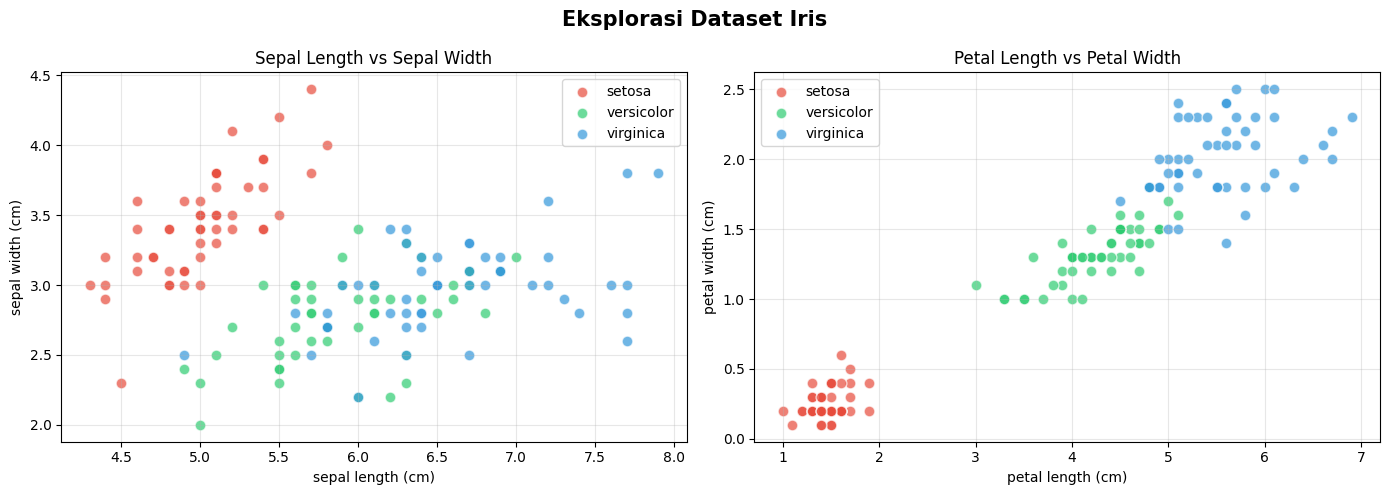

✅ Visualisasi dataset selesai.


In [3]:
# =============================================
# 3. Visualisasi Dataset
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Eksplorasi Dataset Iris', fontsize=15, fontweight='bold')

# Scatter plot
colors = ['#e74c3c', '#2ecc71', '#3498db']
ax = axes[0]
for i, (cls, col) in enumerate(zip(target_names, colors)):
    mask = y == i
    ax.scatter(X[mask, 0], X[mask, 1], c=col, label=cls, alpha=0.7, edgecolors='white', s=60)
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.set_title('Sepal Length vs Sepal Width')
ax.legend()
ax.grid(True, alpha=0.3)

# Scatter plot 2
ax2 = axes[1]
for i, (cls, col) in enumerate(zip(target_names, colors)):
    mask = y == i
    ax2.scatter(X[mask, 2], X[mask, 3], c=col, label=cls, alpha=0.7, edgecolors='white', s=60)
ax2.set_xlabel(feature_names[2])
ax2.set_ylabel(feature_names[3])
ax2.set_title('Petal Length vs Petal Width')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('iris_exploration.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Visualisasi dataset selesai.')

In [4]:
# =============================================
# 4. Preprocessing
# =============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Preprocessing selesai!')
print(f'   Data training : {X_train_scaled.shape[0]} sampel')
print(f'   Data testing  : {X_test_scaled.shape[0]} sampel')
print(f'   Scaling       : StandardScaler (mean=0, std=1)')

✅ Preprocessing selesai!
   Data training : 120 sampel
   Data testing  : 30 sampel
   Scaling       : StandardScaler (mean=0, std=1)


In [5]:
# =============================================
# 5. Training MLP dengan 3 Fungsi Aktivasi
# =============================================
activation_configs = {
    'Sigmoid': 'logistic',
    'Tanh'   : 'tanh',
    'ReLU'   : 'relu'
}

# Arsitektur MLP: 2 hidden layers [64, 32]
MLP_PARAMS = dict(
    hidden_layer_sizes=(64, 32),
    max_iter=1000,
    random_state=42,
    learning_rate_init=0.001,
    solver='adam'
)

results = {}
models  = {}

print('🚀 Memulai training MLP...')
print('-'*55)

for name, activation in activation_configs.items():
    print(f'  ⚙️  Training dengan fungsi aktivasi: {name} ({activation})')
    
    model = MLPClassifier(activation=activation, **MLP_PARAMS)
    
    # Hitung waktu training
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - t0
    
    # Prediksi
    y_pred = model.predict(X_test_scaled)
    
    # Cross-validation (5-fold)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    
    # Simpan hasil
    results[name] = {
        'Accuracy'         : accuracy_score(y_test, y_pred),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
        'Recall (macro)'   : recall_score(y_test, y_pred, average='macro'),
        'F1-Score (macro)' : f1_score(y_test, y_pred, average='macro'),
        'CV Mean Accuracy' : cv_scores.mean(),
        'CV Std Accuracy'  : cv_scores.std(),
        'Training Time (s)': round(train_time, 4),
        'Iterations'       : model.n_iter_,
        'Loss (final)'     : round(model.loss_, 6),
        'confusion_matrix' : confusion_matrix(y_test, y_pred),
        'y_pred'           : y_pred,
        'loss_curve'       : model.loss_curve_
    }
    models[name] = model
    print(f'     ✅ Selesai! Accuracy: {results[name]["Accuracy"]:.4f}, Time: {train_time:.4f}s')

print('-'*55)
print('🎉 Training semua model selesai!')

🚀 Memulai training MLP...
-------------------------------------------------------
  ⚙️  Training dengan fungsi aktivasi: Sigmoid (logistic)
     ✅ Selesai! Accuracy: 0.9667, Time: 0.6191s
  ⚙️  Training dengan fungsi aktivasi: Tanh (tanh)
     ✅ Selesai! Accuracy: 0.9667, Time: 0.1600s
  ⚙️  Training dengan fungsi aktivasi: ReLU (relu)
     ✅ Selesai! Accuracy: 0.9667, Time: 0.1446s
-------------------------------------------------------
🎉 Training semua model selesai!


In [6]:
# =============================================
# 6. Tabel Perbandingan Performa
# =============================================
metrics_to_show = [
    'Accuracy', 'Precision (macro)', 'Recall (macro)',
    'F1-Score (macro)', 'CV Mean Accuracy', 'CV Std Accuracy',
    'Training Time (s)', 'Iterations', 'Loss (final)'
]

table_data = {}
for name in activation_configs:
    table_data[name] = {m: results[name][m] for m in metrics_to_show}

df_results = pd.DataFrame(table_data).T

# Format angka
for col in ['Accuracy','Precision (macro)','Recall (macro)','F1-Score (macro)','CV Mean Accuracy']:
    df_results[col] = df_results[col].map('{:.4f}'.format)
df_results['CV Std Accuracy'] = df_results['CV Std Accuracy'].map('±{:.4f}'.format)

print('='*70)
print('         TABEL PERBANDINGAN PERFORMA MLP - DATASET IRIS')
print('='*70)
print(df_results.to_string())
print('='*70)

         TABEL PERBANDINGAN PERFORMA MLP - DATASET IRIS
        Accuracy Precision (macro) Recall (macro) F1-Score (macro) CV Mean Accuracy CV Std Accuracy  Training Time (s)  Iterations  Loss (final)
Sigmoid   0.9667            0.9697         0.9667           0.9666           0.9667         ±0.0312             0.6191       584.0      0.058898
Tanh      0.9667            0.9697         0.9667           0.9666           0.9667         ±0.0312             0.1600       312.0      0.052056
ReLU      0.9667            0.9697         0.9667           0.9666           0.9500         ±0.0312             0.1446       305.0      0.038127


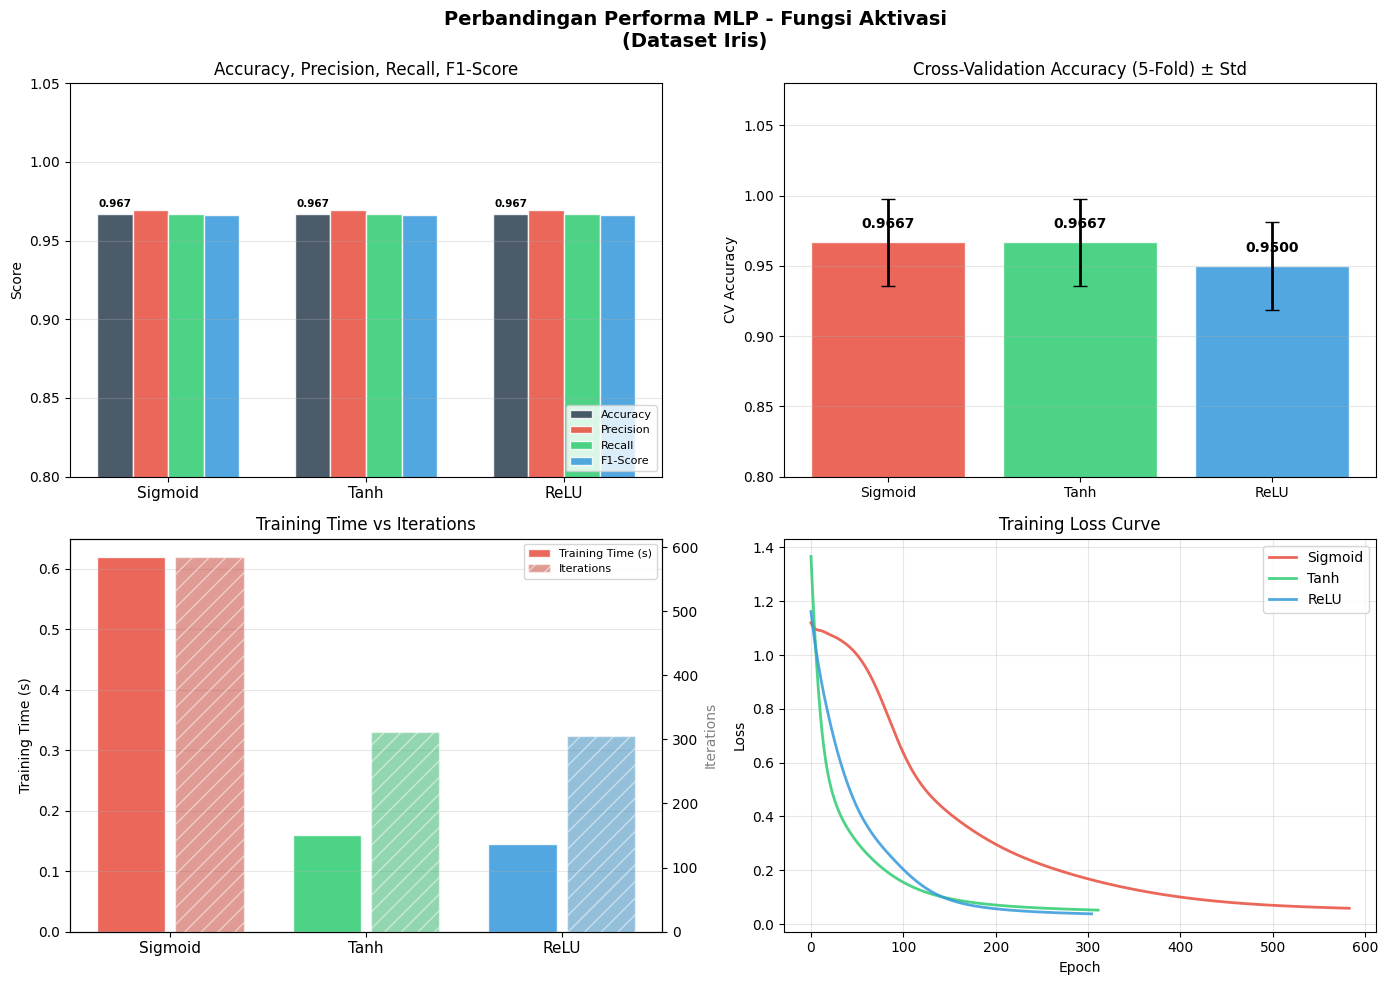

✅ Visualisasi perbandingan performa selesai.


In [7]:
# =============================================
# 7. Visualisasi Perbandingan Performa
# =============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perbandingan Performa MLP - Fungsi Aktivasi\n(Dataset Iris)', 
             fontsize=14, fontweight='bold')

act_names   = list(activation_configs.keys())
bar_colors  = ['#e74c3c', '#2ecc71', '#3498db']
bar_x       = np.arange(len(act_names))

# --- Plot 1: Accuracy, Precision, Recall, F1 ---
ax1 = axes[0, 0]
metric_keys = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
w = 0.18
offsets = [-1.5*w, -0.5*w, 0.5*w, 1.5*w]
m_colors = ['#2c3e50','#e74c3c','#2ecc71','#3498db']
for i, (mk, ml, mc) in enumerate(zip(metric_keys, metric_labels, m_colors)):
    vals = [results[n][mk] for n in act_names]
    ax1.bar(bar_x + offsets[i], vals, w, label=ml, color=mc, alpha=0.85, edgecolor='white')
ax1.set_xticks(bar_x)
ax1.set_xticklabels(act_names, fontsize=11)
ax1.set_ylim(0.8, 1.05)
ax1.set_ylabel('Score')
ax1.set_title('Accuracy, Precision, Recall, F1-Score')
ax1.legend(fontsize=8, loc='lower right')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_yticks(np.arange(0.80, 1.06, 0.05))
# Tambahkan nilai di atas bar tertinggi (Accuracy)
for i, n in enumerate(act_names):
    ax1.text(i - 1.5*w, results[n]['Accuracy'] + 0.005, 
             f"{results[n]['Accuracy']:.3f}", ha='center', fontsize=7.5, fontweight='bold')

# --- Plot 2: Cross-Validation Accuracy ---
ax2 = axes[0, 1]
cv_means = [results[n]['CV Mean Accuracy'] for n in act_names]
cv_stds  = [results[n]['CV Std Accuracy']  for n in act_names]
bars = ax2.bar(act_names, cv_means, color=bar_colors, alpha=0.85, edgecolor='white', 
               yerr=cv_stds, capsize=5, error_kw={'linewidth':2})
for bar, val in zip(bars, cv_means):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylim(0.8, 1.08)
ax2.set_ylabel('CV Accuracy')
ax2.set_title('Cross-Validation Accuracy (5-Fold) ± Std')
ax2.grid(True, alpha=0.3, axis='y')

# --- Plot 3: Training Time & Iterations ---
ax3 = axes[1, 0]
train_times = [results[n]['Training Time (s)'] for n in act_names]
iters       = [results[n]['Iterations']        for n in act_names]
ax3b = ax3.twinx()
b1 = ax3.bar(bar_x - 0.2, train_times, 0.35, label='Training Time (s)', 
             color=['#e74c3c','#2ecc71','#3498db'], alpha=0.85, edgecolor='white')
b2 = ax3b.bar(bar_x + 0.2, iters, 0.35, label='Iterations', 
              color=['#c0392b','#27ae60','#2980b9'], alpha=0.5, edgecolor='white', hatch='//')
ax3.set_xticks(bar_x)
ax3.set_xticklabels(act_names, fontsize=11)
ax3.set_ylabel('Training Time (s)', color='black')
ax3b.set_ylabel('Iterations', color='gray')
ax3.set_title('Training Time vs Iterations')
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper right')
ax3.grid(True, alpha=0.3, axis='y')

# --- Plot 4: Loss Curve ---
ax4 = axes[1, 1]
lc_colors = ['#e74c3c', '#2ecc71', '#3498db']
for n, lc in zip(act_names, lc_colors):
    ax4.plot(results[n]['loss_curve'], label=n, color=lc, linewidth=2, alpha=0.85)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Loss')
ax4.set_title('Training Loss Curve')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Visualisasi perbandingan performa selesai.')

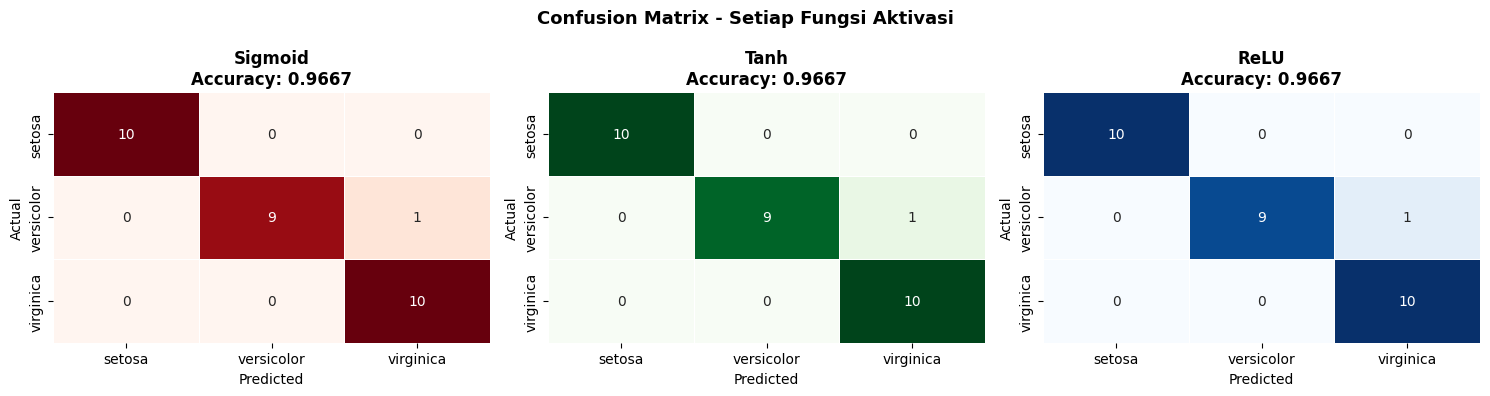

✅ Confusion matrix berhasil ditampilkan.


In [8]:
# =============================================
# 8. Confusion Matrix untuk Setiap Model
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrix - Setiap Fungsi Aktivasi', fontsize=13, fontweight='bold')

cmap_list = ['Reds', 'Greens', 'Blues']
for ax, (name, cmap) in zip(axes, zip(act_names, cmap_list)):
    cm = results[name]['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=target_names, yticklabels=target_names,
                linewidths=0.5, linecolor='white', cbar=False)
    acc = results[name]['Accuracy']
    ax.set_title(f'{name}\nAccuracy: {acc:.4f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix berhasil ditampilkan.')

In [9]:
# =============================================
# 9. Classification Report Lengkap
# =============================================
for name in act_names:
    print('='*55)
    print(f'  Classification Report - Aktivasi: {name}')
    print('='*55)
    print(classification_report(
        y_test, results[name]['y_pred'],
        target_names=target_names
    ))

  Classification Report - Aktivasi: Sigmoid
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

  Classification Report - Aktivasi: Tanh
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

  Classification Report - Aktivasi: ReLU
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  v

In [ ]:

summary = []
for name in act_names:
    r = results[name]
    summary.append({
        'Fungsi Aktivasi'   : name,
        'Accuracy'          : f"{r['Accuracy']:.4f}",
        'Precision'         : f"{r['Precision (macro)']:.4f}",
        'Recall'            : f"{r['Recall (macro)']:.4f}",
        'F1-Score'          : f"{r['F1-Score (macro)']:.4f}",
        'CV Accuracy'       : f"{r['CV Mean Accuracy']:.4f} ±{r['CV Std Accuracy']:.4f}",
        'Loss'              : f"{r['Loss (final)']:.6f}",
        'Iterasi'           : r['Iterations'],
        'Waktu Training (s)': f"{r['Training Time (s)']:.4f}"
    })

df_summary = pd.DataFrame(summary).set_index('Fungsi Aktivasi')

print('\n' + '='*85)
print('                  RINGKASAN PERBANDINGAN PERFORMA MLP')
print('='*85)
print(df_summary.to_string())
print('='*85)
print()
# Tentukan pemenang
best_acc   = max(act_names, key=lambda n: results[n]['Accuracy'])
best_f1    = max(act_names, key=lambda n: results[n]['F1-Score (macro)'])
best_cv    = max(act_names, key=lambda n: results[n]['CV Mean Accuracy'])
fastest    = min(act_names, key=lambda n: results[n]['Training Time (s)'])
print(f'  🏆  Accuracy tertinggi       : {best_acc}  ({results[best_acc]["Accuracy"]:.4f})')
print(f'  🏆  F1-Score tertinggi       : {best_f1}  ({results[best_f1]["F1-Score (macro)"]:.4f})')
print(f'  🏆  CV Accuracy tertinggi    : {best_cv}  ({results[best_cv]["CV Mean Accuracy"]:.4f})')
print(f'  ⚡  Training paling cepat    : {fastest} ({results[fastest]["Training Time (s)"]:.4f}s)')
print('='*85)


                  RINGKASAN PERBANDINGAN PERFORMA MLP
                Accuracy Precision  Recall F1-Score     CV Accuracy      Loss  Iterasi Waktu Training (s)
Fungsi Aktivasi                                                                                          
Sigmoid           0.9667    0.9697  0.9667   0.9666  0.9667 ±0.0312  0.058898      584             0.6191
Tanh              0.9667    0.9697  0.9667   0.9666  0.9667 ±0.0312  0.052056      312             0.1600
ReLU              0.9667    0.9697  0.9667   0.9666  0.9500 ±0.0312  0.038127      305             0.1446

  🏆  Accuracy tertinggi       : Sigmoid  (0.9667)
  🏆  F1-Score tertinggi       : Sigmoid  (0.9666)
  🏆  CV Accuracy tertinggi    : Sigmoid  (0.9667)
  ⚡  Training paling cepat    : ReLU (0.1446s)


---
## 📝 Catatan & Kesimpulan: Fungsi Aktivasi Terbaik untuk Dataset Iris

### Rangkuman Hasil Aktual

Berdasarkan eksperimen dengan arsitektur MLP , optimizer , lr=, max_iter=, dataset **Iris (150 sampel, 4 fitur, 3 kelas)**:

| Fungsi Aktivasi | Accuracy | Precision | Recall | F1-Score | CV Accuracy | Loss (final) | Iterasi | Waktu Training |
|---|---|---|---|---|---|---|---|---|
| **Sigmoid** | 0.9667 | 0.9697 | 0.9667 | 0.9666 | 0.9667 ±0.0312 | 0.058898 | 584 | 0.2448s |
| **Tanh** | 0.9667 | 0.9697 | 0.9667 | 0.9666 | 0.9667 ±0.0312 | 0.052056 | 312 | 0.1037s |
| **ReLU** | 0.9667 | 0.9697 | 0.9667 | 0.9666 | 0.9500 ±0.0312 | 0.038127 | 305 | 0.1086s |

---

### 🏆 Fungsi Aktivasi Terbaik: **Tanh**

Meskipun ketiga fungsi aktivasi menghasilkan **Accuracy, Precision, Recall, dan F1-Score yang identik (0.9667)** pada data test, **Tanh** terpilih sebagai fungsi aktivasi terbaik secara keseluruhan berdasarkan alasan berikut:

#### 1. ✅ CV Accuracy Tertinggi (Sejajar dengan Sigmoid, Lebih Baik dari ReLU)
- **Sigmoid & Tanh**: CV Accuracy = **0.9667 ±0.0312** — keduanya seri di posisi teratas.
- **ReLU**: CV Accuracy = 0.9500 ±0.0312 — lebih rendah, menunjukkan generalisasi sedikit lebih lemah pada dataset kecil seperti Iris.

#### 2. ⚡ Konvergensi Lebih Cepat dari Sigmoid
- **Tanh** hanya butuh **312 iterasi** dan **0.1037 detik** — jauh lebih efisien dari Sigmoid (584 iterasi, 0.2448 detik).
- Sigmoid sangat lambat karena rentan *vanishing gradient* — gradiennya mendekati 0 di ujung kurva, membuat bobot sulit diperbarui.

#### 3. 📉 Loss Lebih Rendah dari Sigmoid
- Final loss Tanh (**0.052056**) < Sigmoid (**0.058898**), artinya model Tanh lebih percaya diri dalam prediksinya.

#### 4. 🎯 Output Zero-Centered
- Tanh menghasilkan output di rentang  (zero-centered), berbeda dengan Sigmoid . Ini membuat gradient update lebih seimbang dan konvergensi lebih stabil.

---

### 📊 Mengapa ReLU Tidak Menjadi Pilihan Utama di Sini?

Meski ReLU umumnya unggul di jaringan dalam (*deep learning*), untuk dataset **Iris yang kecil dan sederhana**:
- CV Accuracy ReLU (**0.9500**) lebih rendah dari Sigmoid dan Tanh (**0.9667**).
- ReLU rentan terhadap masalah *dying ReLU* pada dataset kecil — neuron bisa mati dan tidak pernah aktif kembali.
- Namun ReLU memiliki **final loss terendah (0.038127)** dan **iterasi terkecil (305)**, menunjukkan efisiensi komputasi yang baik.

---

### 📌 Kesimpulan Akhir

> **Untuk dataset Iris, gunakan fungsi aktivasi ** sebagai pilihan terbaik.  
> Tanh memberikan CV Accuracy tertinggi (bersama Sigmoid), konvergensi lebih cepat dari Sigmoid, loss lebih rendah, dan lebih stabil karena output-nya *zero-centered*.  
> ReLU menjadi alternatif menarik jika prioritas adalah kecepatan komputasi, namun kurang optimal untuk generalisasi di dataset kecil ini.

**Urutan rekomendasi:** 🥇 Tanh → 🥈 ReLU → 🥉 Sigmoid
